In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression,SGDRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

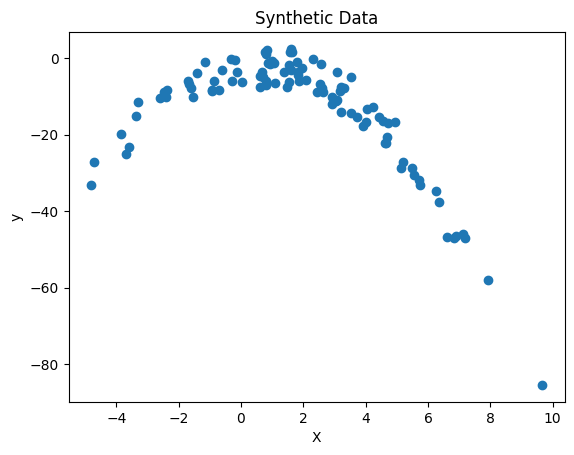

In [6]:
# Generating synthetic data
np.random.seed(0)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - (X ** 2) + np.random.normal(-3, 3, 100)

plt.plot(X, y, 'o')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Data')
plt.show()

In [7]:
# Using without polynomial features
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.40515936936627595

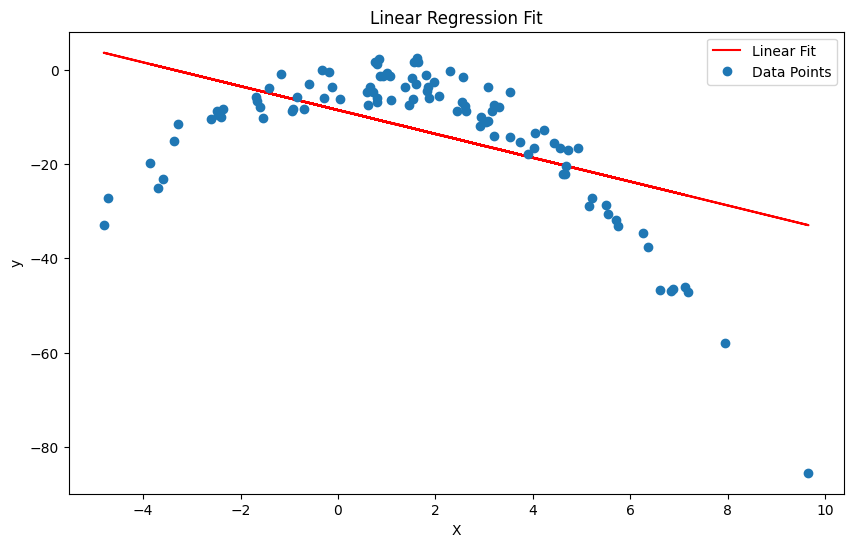

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(X_train , lr.predict(X_train) , color='red' , label='Linear Fit')
plt.plot(X, y, 'o', label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

In [16]:
# Applying polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(X_train_poly[0])
print(X_train[0])

[1.         0.71500439 0.51123128]
[0.71500439]


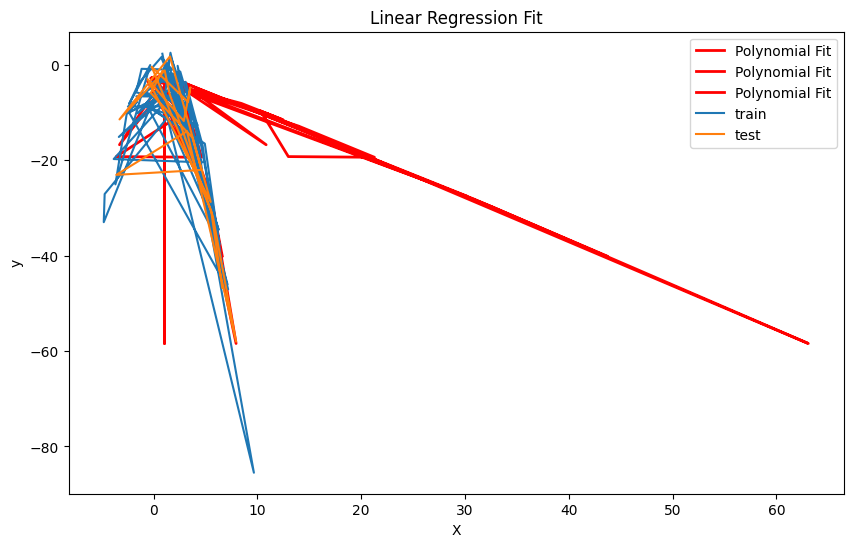

In [ ]:
# Aoolying linear regression on polynomial features
lr_poly = LinearRegression()

lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

plt.figure(figsize=(10, 6))
plt.plot(X_test_poly , y_pred_poly , color='red' ,linewidth=2, label='Polynomial Fit')
plt.plot(X_train, y_train, 'b-', label='train')
plt.plot(X_test, y_test, 'g-', label='test')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

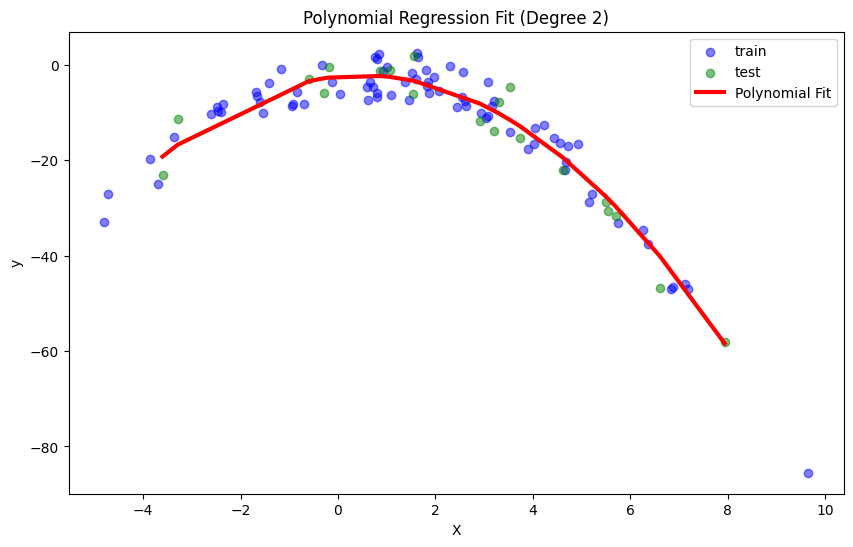

In [36]:
import numpy as np

# 1. Sort the test data so the line flows smoothly from left to right
# We get the sorted indices of X_test
sort_idx = np.argsort(X_test.flatten())
X_test_sorted = X_test[sort_idx]
y_pred_sorted = y_pred_poly[sort_idx]

plt.figure(figsize=(10, 6))

# Use scatter for the actual data points
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='train')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='test')

# Use plot for the prediction, but use the SORTED values
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=3, label='Polynomial Fit')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Polynomial Regression Fit (Degree 2)')
plt.legend()
plt.show()

In [31]:
sort_idx

array([15,  9,  6, 18,  2, 19, 10, 11,  8,  5, 14,  3,  4, 17, 16,  7,  1,
       12,  0, 13])

In [33]:
X_test.flatten()

array([ 6.60873106,  5.54189655, -0.18727169,  3.3142229 ,  3.52895655,
        2.90690825, -0.5933086 ,  5.49544952,  1.56786929, -3.29215704,
        1.0607969 ,  1.53515772,  5.70447746,  7.9423894 ,  3.20953084,
       -3.60267397,  4.61239145,  3.73654899, -0.28311318,  0.86551244])